In [1]:
PATH_WORK_DIR = ".."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_ML


In [4]:
import sys
sys.path.append("src")

# Package

In [ ]:
import analysis

# Load Data

In [ ]:
PATH = "./result/metric"
metric = analysis.metric.loader(PATH)

In [ ]:
PATH = "./result/score"
normal, anomaly = analysis.score.loader(PATH)

# Reconstruction Error Distribution

## Normal

In [8]:
SCORES = (normal["ae"], normal["vae"])
THRESHOLDS = (metric["threshold"]["ae"], metric["threshold"]["vae"])
X_MIN = 0.950
X_MAX = 0.995
SUPTITLE = "Normal"

In [9]:
dropouts = normal["ae"].columns

ae_titles = [
    f"Deterministic (Dropout {dropout})"
    for dropout in dropouts
]

vae_titles = [
    f"Stochastic (Dropout {dropout})"
    for dropout in dropouts
]

TITLES = (ae_titles, vae_titles)

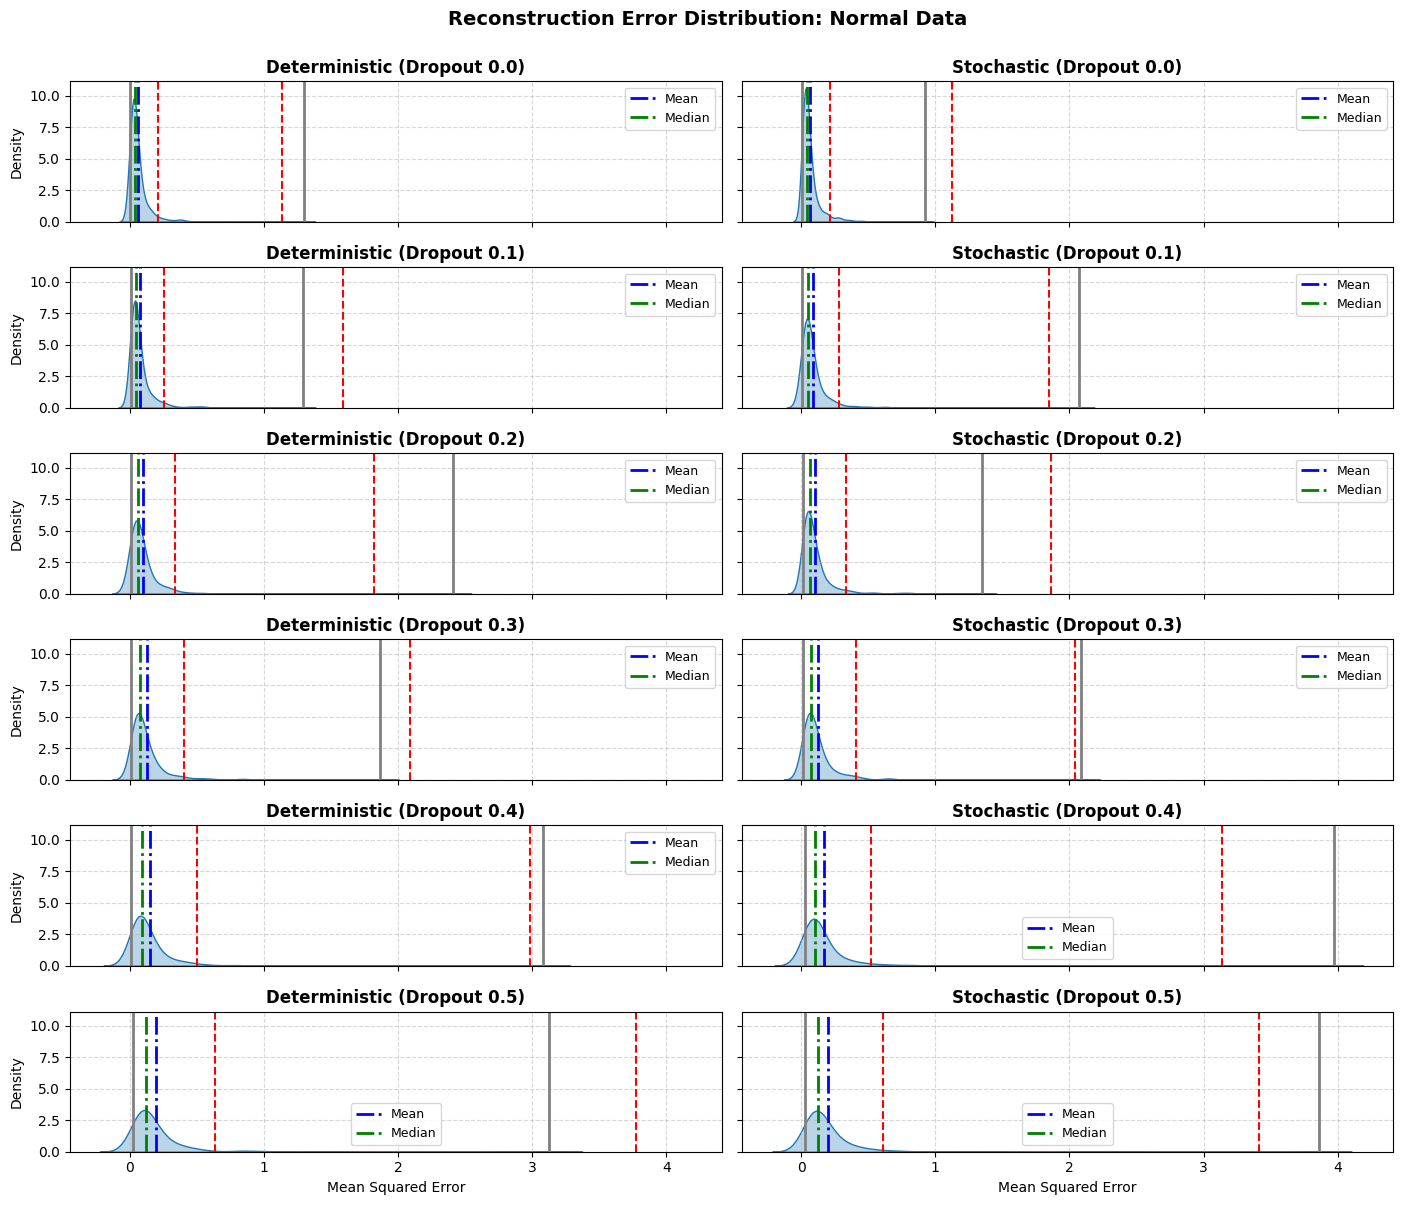

In [10]:
analysis.reconn.draw_plt(
    scores=SCORES, 
    thresholds=THRESHOLDS, 
    x_min=X_MIN,
    x_max=X_MAX,
    suptitle=f"Reconstruction Error Distribution: {SUPTITLE} Data",
    titles=TITLES,
)

## Anomaly

In [11]:
SCORES = (anomaly["ae"], anomaly["vae"])
THRESHOLDS = (metric["threshold"]["ae"], metric["threshold"]["vae"])
X_MIN = 0.950
X_MAX = 0.995
SUPTITLE = "Anomaly"

In [12]:
dropouts = normal["ae"].columns

ae_titles = [
    f"Deterministic (Dropout {dropout})"
    for dropout in dropouts
]

vae_titles = [
    f"Stochastic (Dropout {dropout})"
    for dropout in dropouts
]

TITLES = (ae_titles, vae_titles)

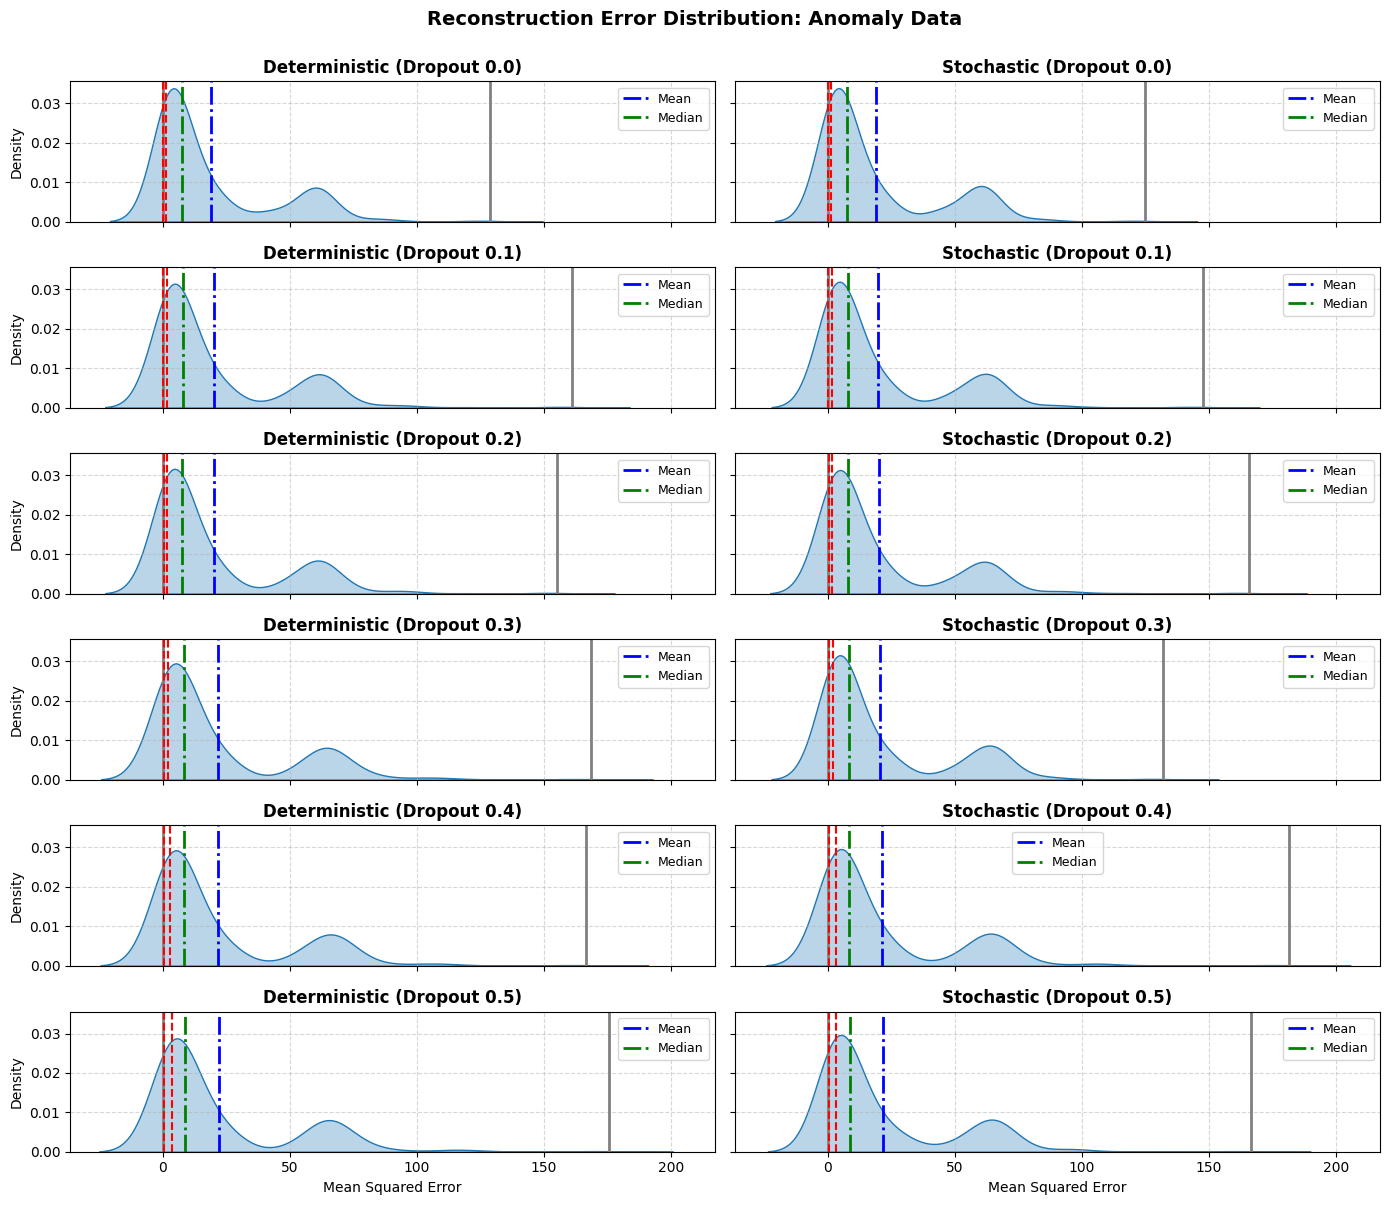

In [13]:
analysis.reconn.draw_plt(
    scores=SCORES, 
    thresholds=THRESHOLDS, 
    x_min=X_MIN,
    x_max=X_MAX,
    suptitle=f"Reconstruction Error Distribution: {SUPTITLE} Data",
    titles=TITLES,
)

# Compare Metrics Gap: Variation

In [14]:
DATA = metric
ORDERS = ["f1", "precision", "recall", "tp", "tn", "fp", "fn"]
SUPTITLE = "Comprehensive Analysis of Probabilistic Smoothing: VI Effects"
STD = 0.97

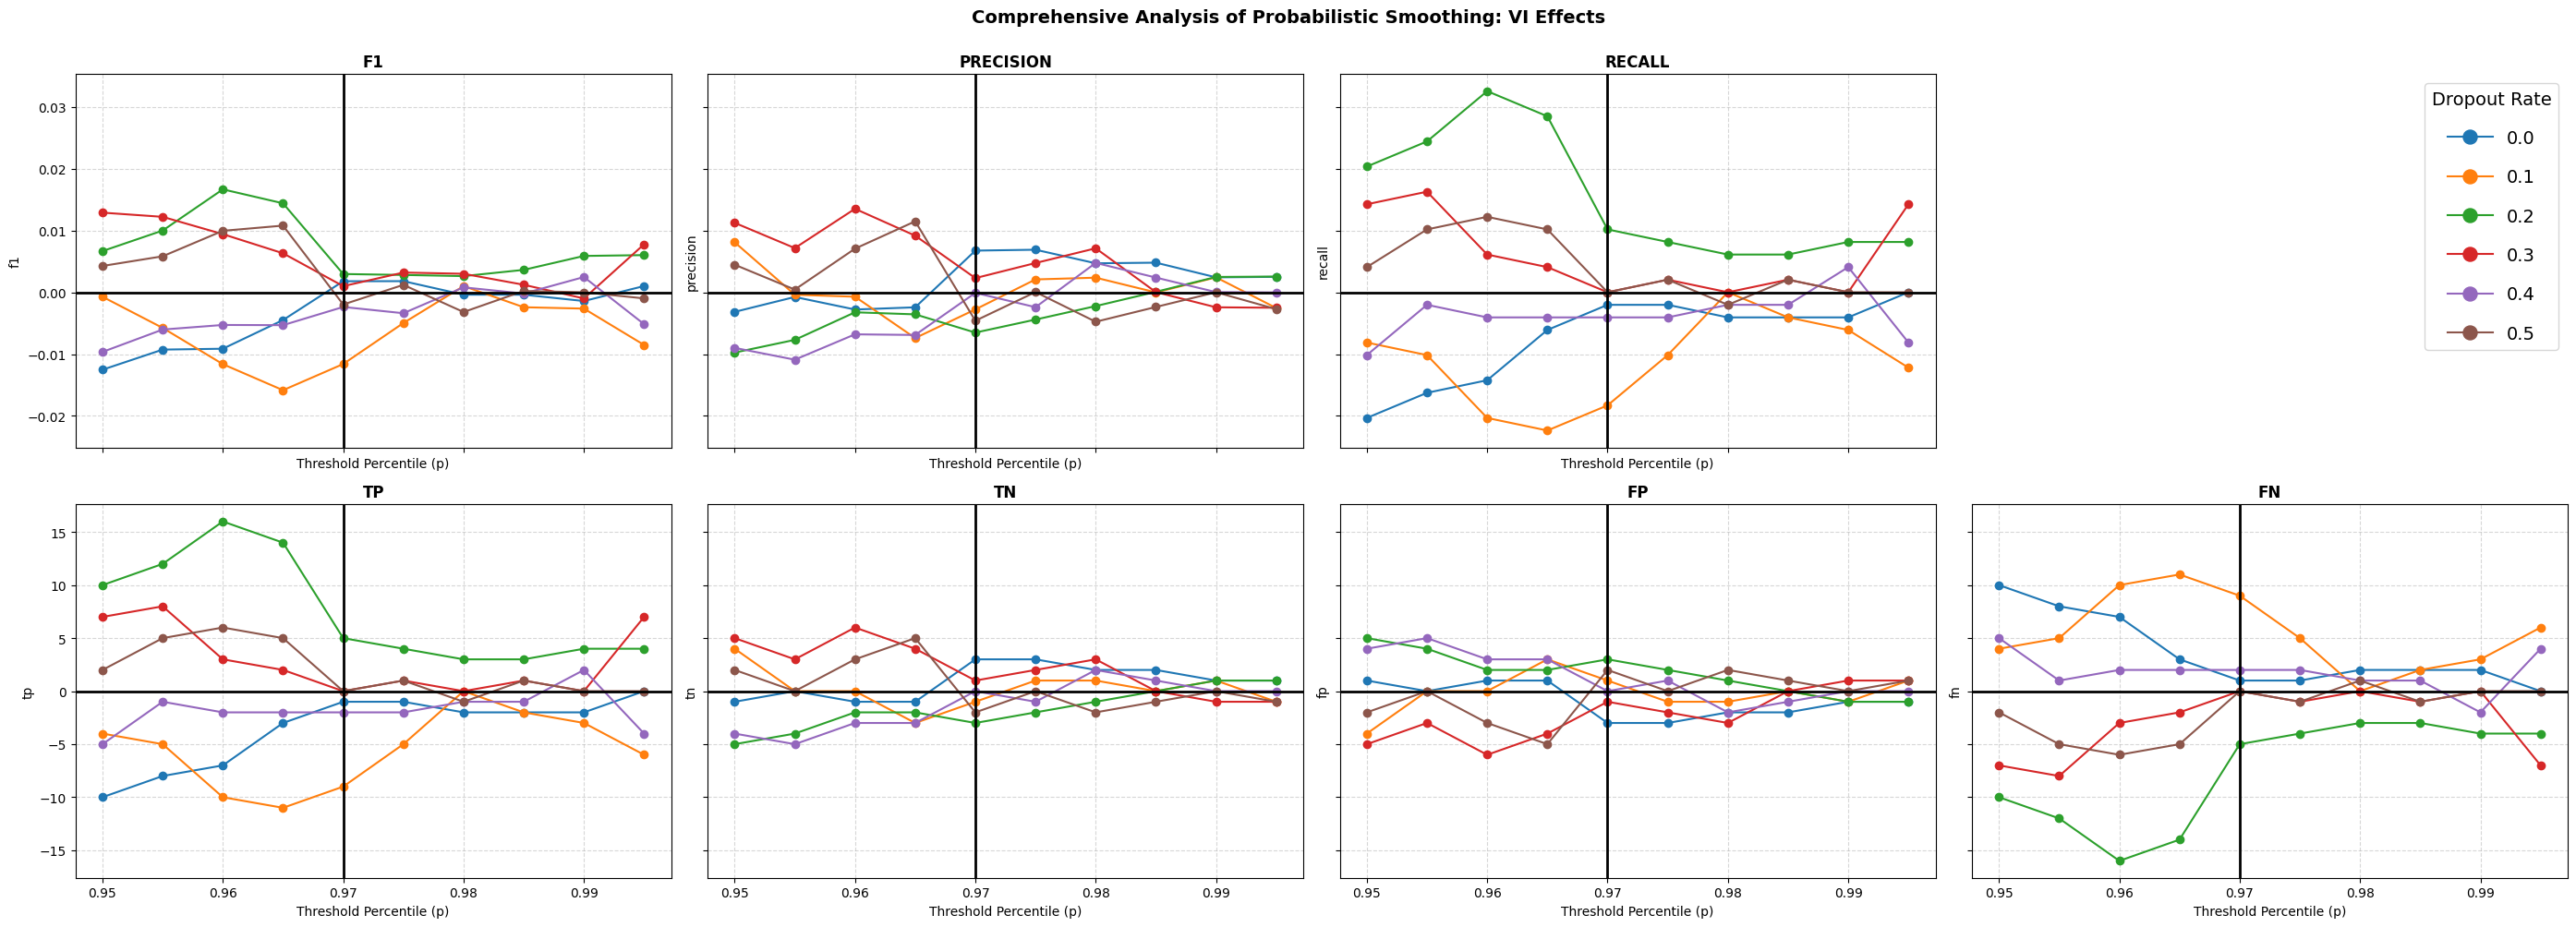

In [15]:
analysis.variation.draw_plt(
    data=DATA,
    orders=ORDERS,
    suptitle=SUPTITLE,
    std=STD,
)

# Compare Metrics Gap: Dropout

In [16]:
DATA = metric
ORDERS = ["f1", "precision", "recall", "tp", "tn", "fp", "fn"]
SUPTITLE = "Comprehensive Analysis of Probabilistic Smoothing: Dropout Effects"
STD = 0.97

In [17]:
ae_titles = [
    f"Deterministic ({order.upper()})"
    for order in ORDERS
]

vae_titles = [
    f"Stochastic ({order.upper()})"
    for order in ORDERS
]

TITLES = (ae_titles, vae_titles)

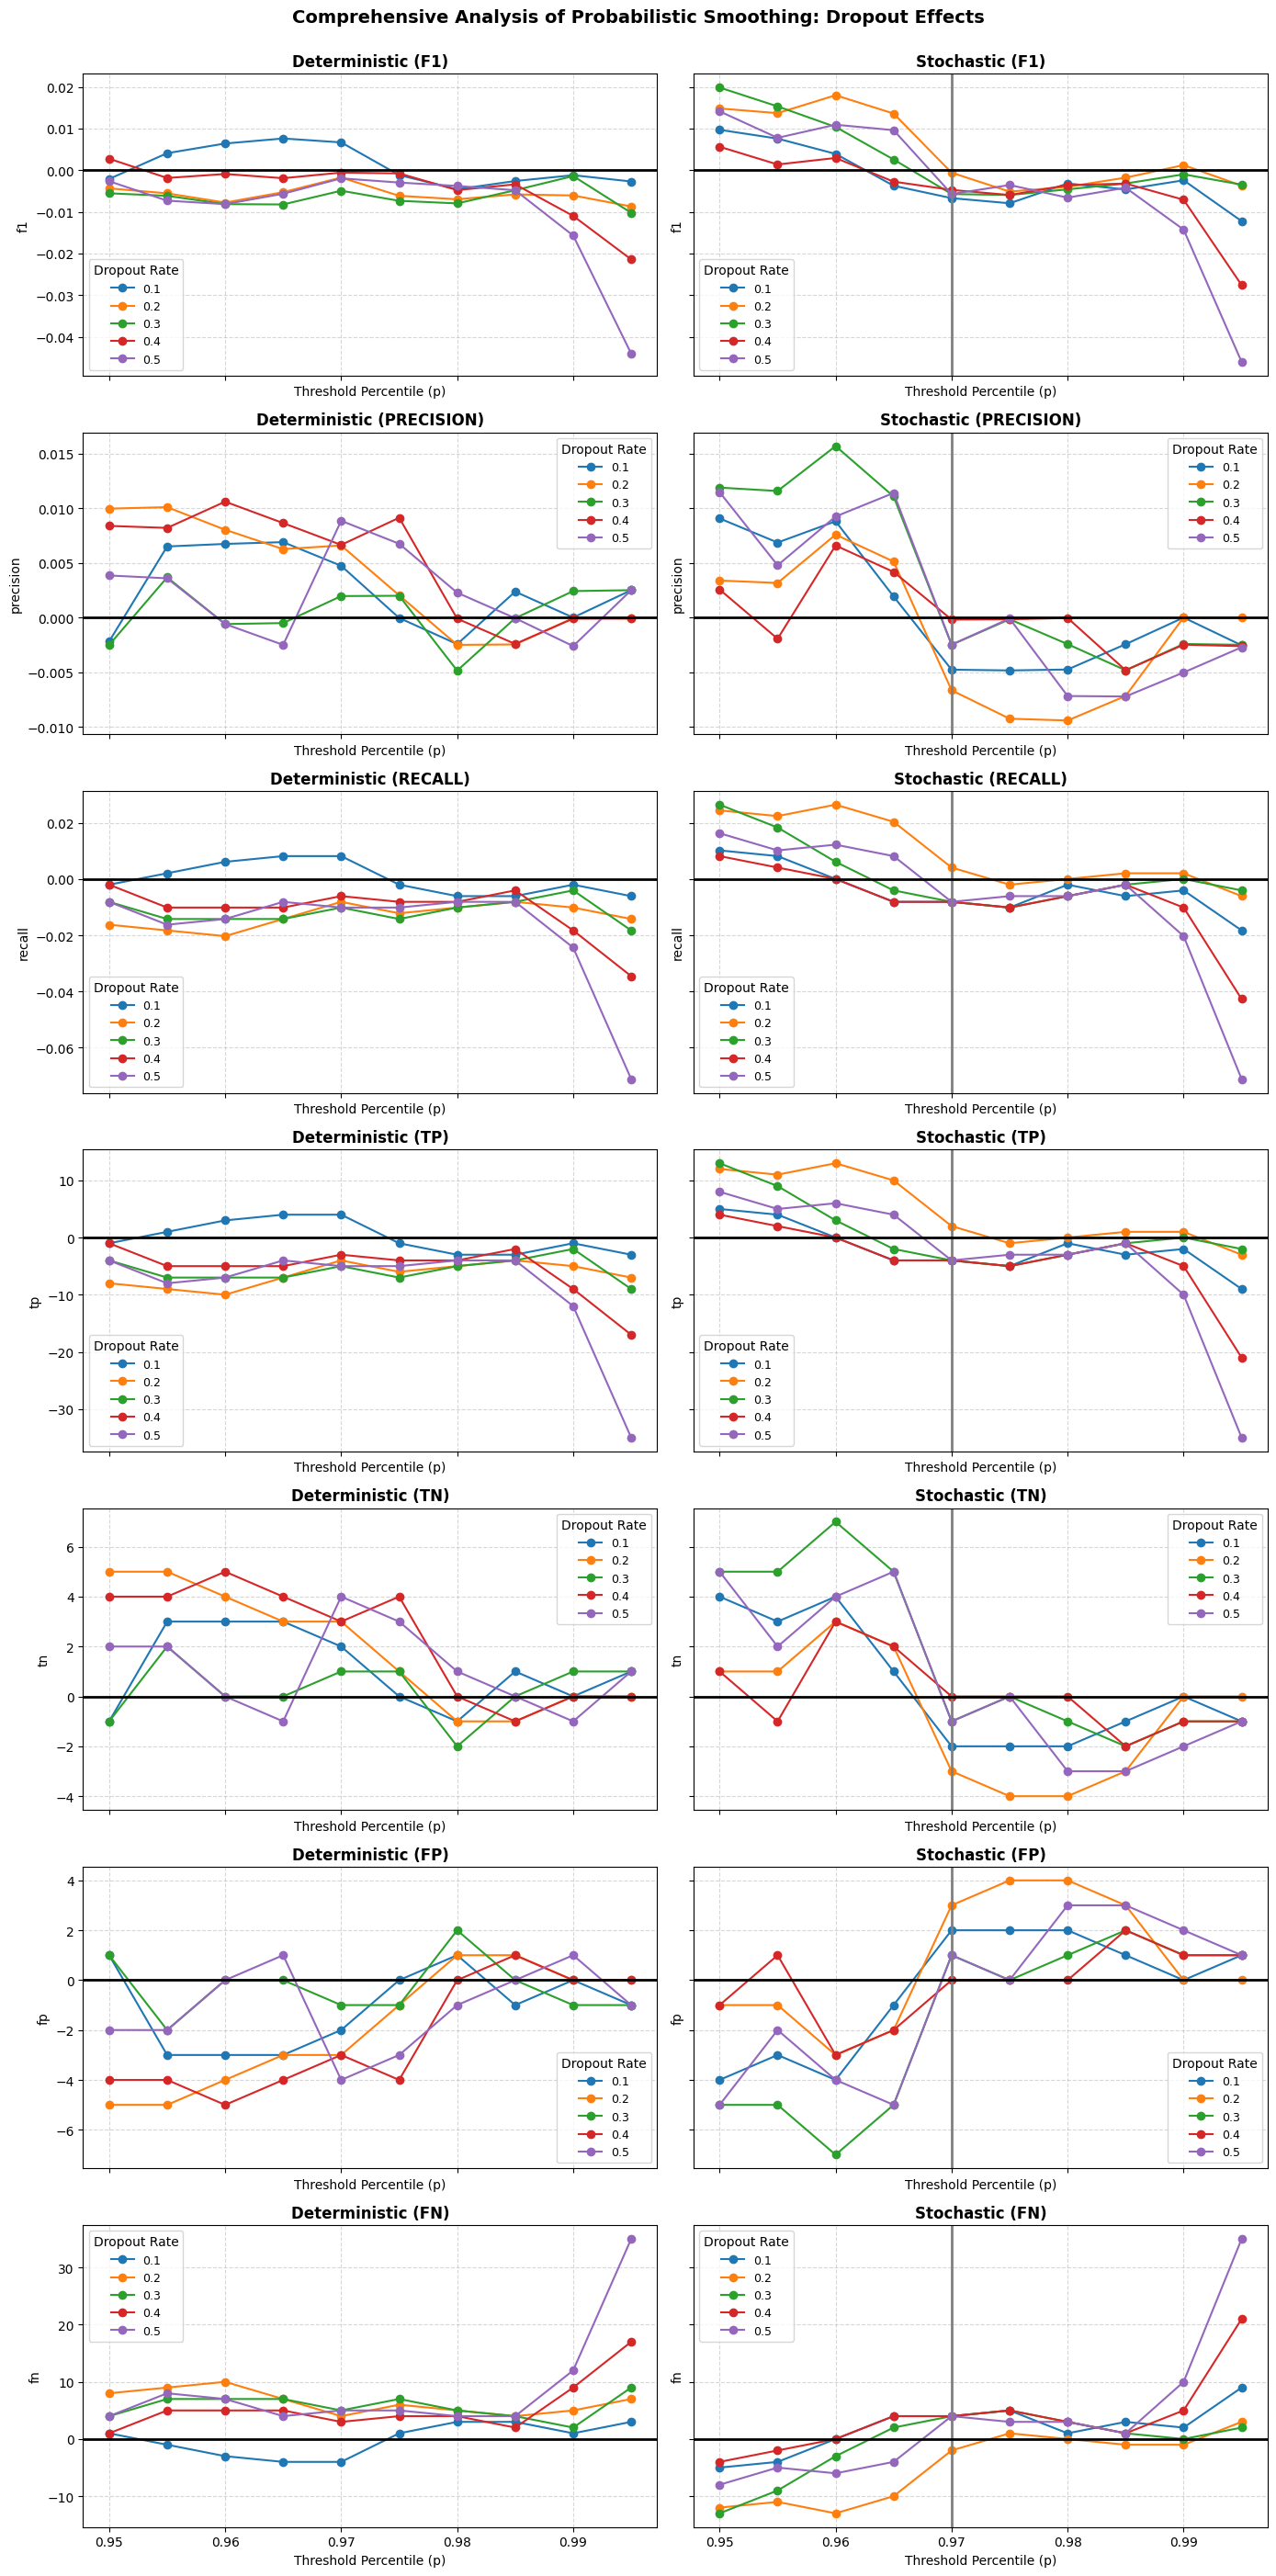

In [18]:
analysis.dropout.draw_plt(
    data=DATA,
    orders=ORDERS,
    suptitle=SUPTITLE,
    titles=TITLES,
    std=STD,
)